In [1]:
!pip install -q transformers datasets scikit-learn seaborn matplotlib accelerate
!pip install -q tables h5py tqdm opencv-python-headless


In [2]:
import os, warnings, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import h5py
import cv2

from pathlib import Path
from tqdm import tqdm
from collections import defaultdict

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.manifold import TSNE

from datasets import Dataset, DatasetDict
from transformers import (
    DistilBertTokenizer,
    DistilBertForSequenceClassification,
    DistilBertModel,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)

import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras import Model
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import load_img, img_to_array

warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch device : {DEVICE}")

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"TensorFlow GPU : {gpus[0].name}")
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print(f"  Memory growth setting: {e}")
else:
    print("TensorFlow GPU : Not detected")

print(f"TensorFlow     : {tf.__version__}")
print(f"PyTorch        : {torch.__version__}")


2026-05-01 23:43:14.429266: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777678994.831780      22 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777678994.945874      22 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777678995.946888      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777678995.946936      22 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777678995.946939      22 computation_placer.cc:177] computation placer alr

PyTorch device : cuda
TensorFlow GPU : /physical_device:GPU:0
TensorFlow     : 2.19.0
PyTorch        : 2.10.0+cu128


In [3]:
TEXT_DATA_PATH    = "/kaggle/input/datasets/maryamabdelfattah/deeplearning/Data20categories.txt"
IMAGE_DATASET_PATH  = "/kaggle/input/datasets/maryamabdelfattah/deeplearning/resized_dataset"
RESIZED_DATASET_PATH = "/kaggle/input/datasets/maryamabdelfattah/deeplearning/resized_dataset/resized_dataset"

WORKING_DIR       = "/kaggle/working"
DISTILBERT_OUT    = "/kaggle/working/distilbert_output"
RESNET_OUT        = "/kaggle/working/resnet_output"
FUSION_OUT        = "/kaggle/working/fusion_output"

MODEL_NAME   = "distilbert-base-uncased"
MAX_LENGTH   = 64
BATCH_SIZE   = 32
EPOCHS       = 6
LR           = 2e-5
WEIGHT_DECAY = 0.01
SEED         = 42
IMAGE_SIZE   = 224
FREEZE_ALL   = True
VALID_EXTS   = {".jpg", ".jpeg", ".png", ".webp", ".bmp"}

for d in [DISTILBERT_OUT, RESNET_OUT, FUSION_OUT]:
    os.makedirs(d, exist_ok=True)

for d in [DISTILBERT_OUT, RESNET_OUT, FUSION_OUT]:
    print(f"  {d}")


  /kaggle/working/distilbert_output
  /kaggle/working/resnet_output
  /kaggle/working/fusion_output


In [4]:

def verify_path(label, path, is_dir=False):
    exists = os.path.exists(path)
    kind   = "DIR " if is_dir else "FILE"
    mark   = "done" if exists else "not"
    size   = ""
    if exists and not is_dir:
        size = f"  ({os.path.getsize(path)/1e6:.2f} MB)"
    elif exists and is_dir:
        count = sum(1 for _ in Path(path).rglob("*") if _.is_file())
        size  = f"  ({count} files)"
    print(f"  {mark} [{kind}] {label:<25} {path}{size}")
    return exists

print("DATASET PATH VERIFICATION")
text_ok    = verify_path("Text data",    TEXT_DATA_PATH,     is_dir=False)
image_ok   = verify_path("Image root",   IMAGE_DATASET_PATH, is_dir=True)
resized_ok = verify_path("Resized data", RESIZED_DATASET_PATH, is_dir=True)

if resized_ok and len(os.listdir(RESIZED_DATASET_PATH)) > 0:
    DATASET_DIR = RESIZED_DATASET_PATH
    print(f"\n  Using RESIZED_DATASET_PATH as DATASET_DIR")
elif image_ok and len(os.listdir(IMAGE_DATASET_PATH)) > 0:
    DATASET_DIR = IMAGE_DATASET_PATH
    print(f"\n Using IMAGE_DATASET_PATH as DATASET_DIR")
else:
    DATASET_DIR = RESIZED_DATASET_PATH

print(f"\n  DATASET_DIR = {DATASET_DIR}")

if not text_ok:
    print("\n Text data file not found.")


DATASET PATH VERIFICATION
  done [FILE] Text data                 /kaggle/input/datasets/maryamabdelfattah/deeplearning/Data20categories.txt  (0.64 MB)
  done [DIR ] Image root                /kaggle/input/datasets/maryamabdelfattah/deeplearning/resized_dataset  (3693 files)
  done [DIR ] Resized data              /kaggle/input/datasets/maryamabdelfattah/deeplearning/resized_dataset/resized_dataset  (3693 files)

  Using RESIZED_DATASET_PATH as DATASET_DIR

  DATASET_DIR = /kaggle/input/datasets/maryamabdelfattah/deeplearning/resized_dataset/resized_dataset


##  Section 2 — DistilBERT Text Classifier


In [5]:

try:
    df_categories = pd.read_csv(TEXT_DATA_PATH)
    print("File loaded .")
except Exception as e:
    print(f"  Comma delimiter failed: {e}\n  Trying tab delimiter...")
    try:
        df_categories = pd.read_csv(TEXT_DATA_PATH, sep="\t")
        print(" File loaded ")
    except Exception as e2:
        print(f" Both delimiters failed: {e2}")
        df_categories = None

if df_categories is not None:
    print(f"\nShape         : {df_categories.shape[0]:,} rows × {df_categories.shape[1]} columns")
    print(f"Columns       : {list(df_categories.columns)}")
    print(f"Missing values: {df_categories.isnull().sum().sum()}")
    print(f"Duplicates    : {df_categories.duplicated().sum()}")
    display(df_categories.head())

    h5_out = os.path.join(DISTILBERT_OUT, "Data20categories.h5")
    try:
        df_categories.to_hdf(h5_out, key="df", mode="w")
        print(f"\nDataFrame cached → {h5_out}")
    except Exception as e:
        print(f"\n HDF5 save failed: {e}")
else:
    print(" DataFrame could not be loaded")


File loaded .

Shape         : 4,775 rows × 20 columns
Columns       : ['name', 'price', 'keyword', 'Brand Name', 'Flavor', 'Item Weight', 'Item Form', 'actual_weight_gm', 'price_per_kg', 'is_organic', 'is_sugar_free', 'is_gluten_free', 'is_vegan', 'is_keto', 'is_diet', 'is_zero', 'is_stevia', 'pack_size', 'weight_category', 'brand_in_name']
Missing values: 5063
Duplicates    : 1134


,name,price,keyword,Brand Name,Flavor,Item Weight,Item Form,actual_weight_gm,price_per_kg,is_organic,is_sugar_free,is_gluten_free,is_vegan,is_keto,is_diet,is_zero,is_stevia,pack_size,weight_category,brand_in_name
0,juhayna,257.0,milk,juhayna,other,1 Kilograms,liquid,1000.0,257.0,0,0,0,0,0,0,0,0,1.0,large,1
1,almarai,49.0,milk,almarai,other,1 Kilograms,liquid,1000.0,49.0,0,0,0,0,0,0,0,0,1.0,large,1
2,juhayna,515.0,milk,juhayna,other,2 Kilograms,liquid,2000.0,257.5,0,0,0,0,0,0,0,0,1.0,xlarge,1
3,almarai,302.0,milk,almarai,coffee,1 Kilograms,liquid,1000.0,302.0,0,0,0,0,0,0,0,0,1.0,large,1
4,almarai,49.0,milk,almarai,unflavored,1 Kilograms,liquid,1000.0,49.0,0,0,0,0,0,0,0,0,1.0,large,1



DataFrame cached → /kaggle/working/distilbert_output/Data20categories.h5


In [6]:

def preprocess_text_data(df):


    def build_text(row):
        parts = [str(row.get("name", "")).strip()]

        for col, skip_vals in [
            ("Flavor",     {"nan", "other", ""}),
            ("Brand Name", {"nan", "other", "generic", ""}),
        ]:
            val = str(row.get(col, "")).strip().lower()
            if val not in skip_vals:
                parts.append(str(row.get(col, "")).strip())

        flag_map = {
            "organic": row.get("is_organic", 0),
            "sugar-free": row.get("is_sugar_free", 0),
            "vegan": row.get("is_vegan", 0),
            "keto": row.get("is_keto", 0),
        }
        active = [k for k, v in flag_map.items() if v == 1]
        if active:
            parts.append(" ".join(active))

        return " | ".join(p for p in parts if p)

    df = df.copy()
    df["text"]      = df.apply(build_text, axis=1)
    df["label_str"] = df["keyword"].str.strip().str.lower()

    le = LabelEncoder()
    df["label"] = le.fit_transform(df["label_str"])

    print(f"   Samples    : {len(df):,}")
    print(f"   Categories : {len(le.classes_)}")
    print(f"   Labels     : {list(le.classes_)}")
    return df[["text", "label", "label_str"]], le


try:
    df_text, le = preprocess_text_data(df_categories)
    print("\nSample rows:")
    display(df_text.head(3))
except Exception as e:
    print(f" Preprocessing failed: {e}")
    raise


   Samples    : 4,775
   Categories : 20
   Labels     : ['biscuits', 'bread', 'butter', 'cheese', 'chips', 'chocolate', 'flour', 'honey', 'jam', 'juice', 'milk', 'nuts', 'oil', 'pasta', 'rice', 'sauce', 'soap', 'spices', 'sugar', 'yogurt']

Sample rows:


,text,label,label_str
0,juhayna | juhayna,10,milk
1,almarai | almarai,10,milk
2,juhayna | juhayna,10,milk


In [7]:
try:
    train_df, val_df = train_test_split(
        df_text, test_size=0.15, random_state=SEED, stratify=df_text["label"]
    )
    print(f"Train : {len(train_df):,} samples")
    print(f"Val   : {len(val_df):,} samples")

    tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)

    def tokenize_fn(batch):
        return tokenizer(
            batch["text"],
            padding="max_length",
            truncation=True,
            max_length=MAX_LENGTH,
        )

    train_ds = Dataset.from_pandas(train_df.reset_index(drop=True))
    val_ds   = Dataset.from_pandas(val_df.reset_index(drop=True))
    hf_data  = DatasetDict({"train": train_ds, "validation": val_ds})
    hf_data  = hf_data.map(tokenize_fn, batched=True)
    hf_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    print(f"\nDatasets ready:")
    print(hf_data)

except Exception as e:
    print(f" Tokenization failed: {e}")
    raise


Train : 4,058 samples
Val   : 717 samples


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4058 [00:00<?, ? examples/s]

Map:   0%|          | 0/717 [00:00<?, ? examples/s]


Datasets ready:
DatasetDict({
    train: Dataset({
        features: ['text', 'label', 'label_str', 'input_ids', 'attention_mask'],
        num_rows: 4058
    })
    validation: Dataset({
        features: ['text', 'label', 'label_str', 'input_ids', 'attention_mask'],
        num_rows: 717
    })
})


In [8]:
try:
    num_labels = len(le.classes_)
    bert_clf   = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=num_labels
    )
    bert_clf.config.id2label = {i: c for i, c in enumerate(le.classes_)}
    bert_clf.config.label2id = {c: i for i, c in enumerate(le.classes_)}

    total_params     = sum(p.numel() for p in bert_clf.parameters())
    trainable_params = sum(p.numel() for p in bert_clf.parameters() if p.requires_grad)
    print(f"DistilBERT loaded")
    print(f"   Total params     : {total_params/1e6:.1f}M")
    print(f"   Trainable params : {trainable_params/1e6:.1f}M")
    print(f"   Num labels       : {num_labels}")

except Exception as e:
    print(f" Model load failed: {e}")
    raise


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT loaded
   Total params     : 67.0M
   Trainable params : 67.0M
   Num labels       : 20


In [9]:

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {"accuracy": accuracy_score(labels, preds)}

training_args = TrainingArguments(
    output_dir              = DISTILBERT_OUT,
    eval_strategy           = "epoch",
    save_strategy           = "epoch",
    load_best_model_at_end  = True,
    metric_for_best_model   = "accuracy",
    greater_is_better       = True,
    num_train_epochs        = EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    learning_rate           = LR,
    weight_decay            = WEIGHT_DECAY,
    warmup_ratio            = 0.1,
    lr_scheduler_type       = "cosine",
    fp16                    = torch.cuda.is_available(),
    dataloader_num_workers  = 2,
    logging_dir             = f"{DISTILBERT_OUT}/logs",
    logging_steps           = 20,
    report_to               = "none",
    seed                    = SEED,
)

trainer = Trainer(
    model           = bert_clf,
    args            = training_args,
    train_dataset   = hf_data["train"],
    eval_dataset    = hf_data["validation"],
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

try:
    print(" Starting DistilBERT training...")
    train_result = trainer.train()
    print(f"   Final train loss : {train_result.training_loss:.4f}")
except Exception as e:
    print(f"Training failed: {e}")
    raise


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


 Starting DistilBERT training...


Epoch,Training Loss,Validation Loss,Accuracy
1,5.182167,4.439509,0.521618
2,2.796278,2.146250,0.783821
3,1.756771,1.423181,0.877266
4,1.297841,1.155650,0.880056
5,1.106982,1.073829,0.881450
6,1.003332,1.063631,0.885635


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


   Final train loss : 2.3935


In [10]:

try:
    trainer.save_model(DISTILBERT_OUT)
    tokenizer.save_pretrained(DISTILBERT_OUT)
    np.save(f"{DISTILBERT_OUT}/label_classes.npy", le.classes_)

    le_json = {"classes": le.classes_.tolist()}
    with open(f"{DISTILBERT_OUT}/label_encoder.json", "w") as f:
        json.dump(le_json, f, indent=2)

    print(f" DistilBERT model saved → {DISTILBERT_OUT}/")
    print(f"   Files saved:")
    for fn in sorted(os.listdir(DISTILBERT_OUT)):
        fp = os.path.join(DISTILBERT_OUT, fn)
        print(f"     {fn:<45} {os.path.getsize(fp)/1e6:.2f} MB")

except Exception as e:
    print(f" Save failed: {e}")
    raise


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 DistilBERT model saved → /kaggle/working/distilbert_output/
   Files saved:
     Data20categories.h5                           1.88 MB
     checkpoint-128                                0.00 MB
     checkpoint-192                                0.00 MB
     checkpoint-256                                0.00 MB
     checkpoint-320                                0.00 MB
     checkpoint-384                                0.00 MB
     checkpoint-64                                 0.00 MB
     config.json                                   0.00 MB
     label_classes.npy                             0.00 MB
     label_encoder.json                            0.00 MB
     model.safetensors                             267.89 MB
     tokenizer.json                                0.71 MB
     tokenizer_config.json                         0.00 MB
     training_args.bin                             0.01 MB


In [11]:
try:
    val_tok = Dataset.from_pandas(val_df.reset_index(drop=True))
    val_tok = val_tok.map(tokenize_fn, batched=True)
    val_tok.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

    preds_out = trainer.predict(val_tok)
    y_pred    = np.argmax(preds_out.predictions, axis=-1)
    y_true    = preds_out.label_ids

    acc = accuracy_score(y_true, y_pred)
    print(f" Validation Accuracy : {acc * 100:.2f}%")
    print()
    print(classification_report(y_true, y_pred, target_names=list(le.classes_)))

    # Save evaluation results
    eval_results = {
        "validation_accuracy": float(acc),
        "classification_report": classification_report(
            y_true, y_pred, target_names=list(le.classes_), output_dict=True
        ),
    }
    with open(f"{DISTILBERT_OUT}/eval_results.json", "w") as f:
        json.dump(eval_results, f, indent=2)
    print(f"\nEvaluation results saved → {DISTILBERT_OUT}/eval_results.json")

except Exception as e:
    print(f"Evaluation failed: {e}")


Map:   0%|          | 0/717 [00:00<?, ? examples/s]

 Validation Accuracy : 88.56%

              precision    recall  f1-score   support

    biscuits       0.95      0.92      0.93        61
       bread       1.00      0.20      0.33         5
      butter       0.88      0.95      0.91        22
      cheese       0.91      1.00      0.95        58
       chips       0.84      0.72      0.78        29
   chocolate       0.87      0.95      0.91        21
       flour       0.90      0.96      0.93        28
       honey       0.98      1.00      0.99        63
         jam       1.00      1.00      1.00        24
       juice       1.00      0.94      0.97        18
        milk       0.90      0.86      0.88        22
        nuts       0.93      0.91      0.92        47
         oil       0.91      0.77      0.83        13
       pasta       0.72      0.70      0.71        37
        rice       0.64      0.61      0.62        38
       sauce       0.82      0.85      0.83        80
        soap       1.00      1.00      1.00       

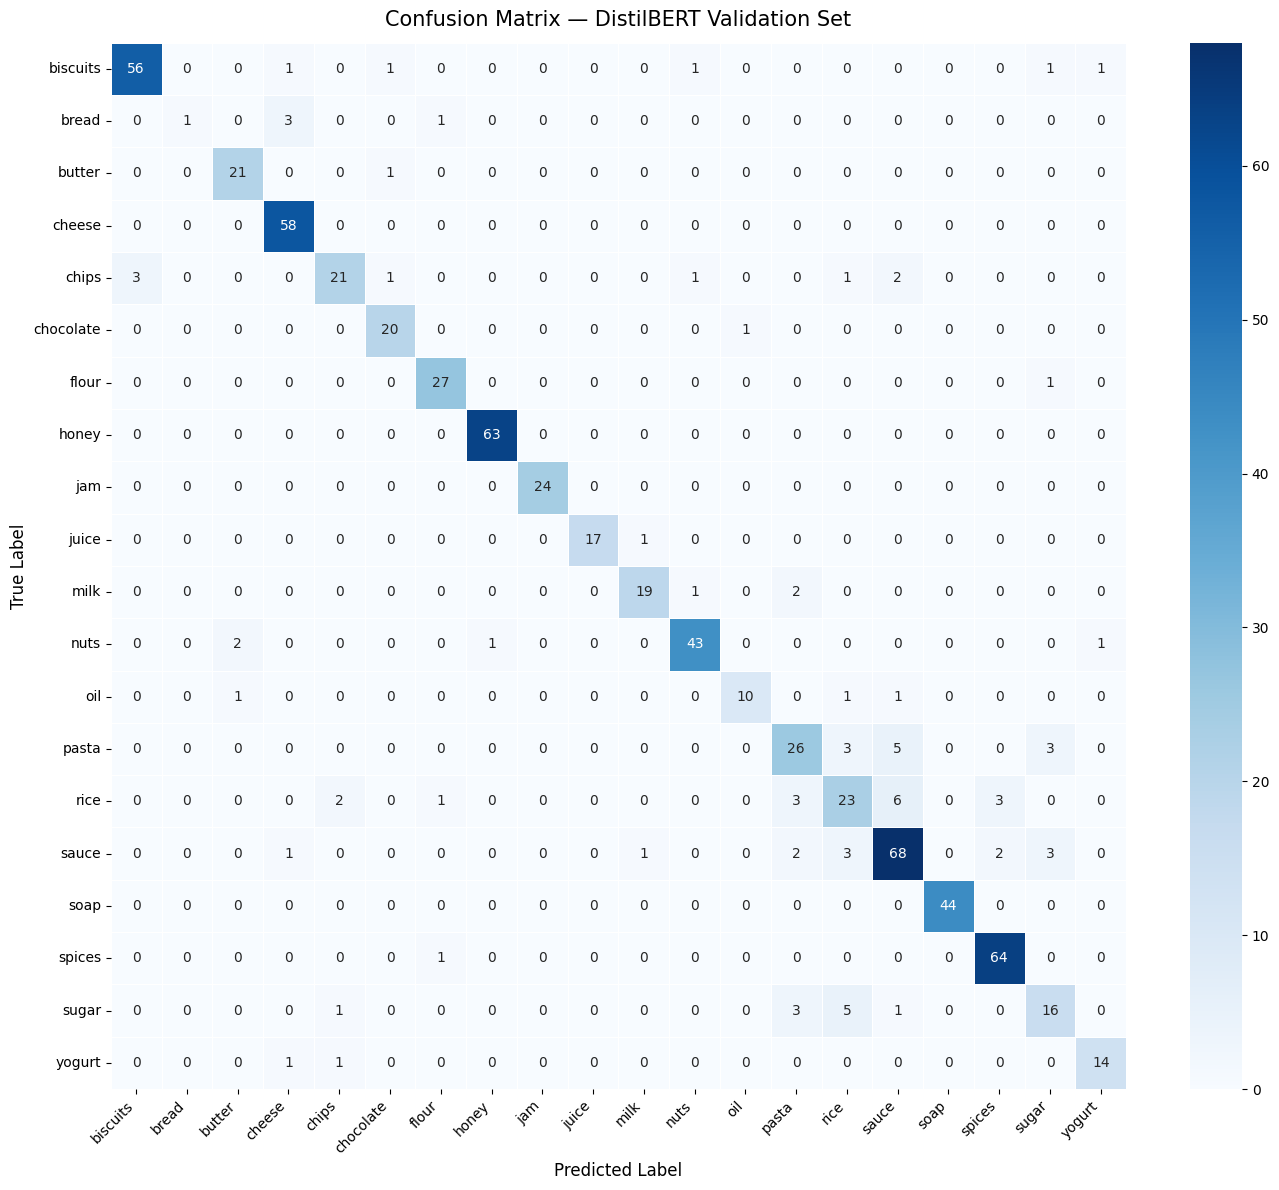

Confusion matrix saved.


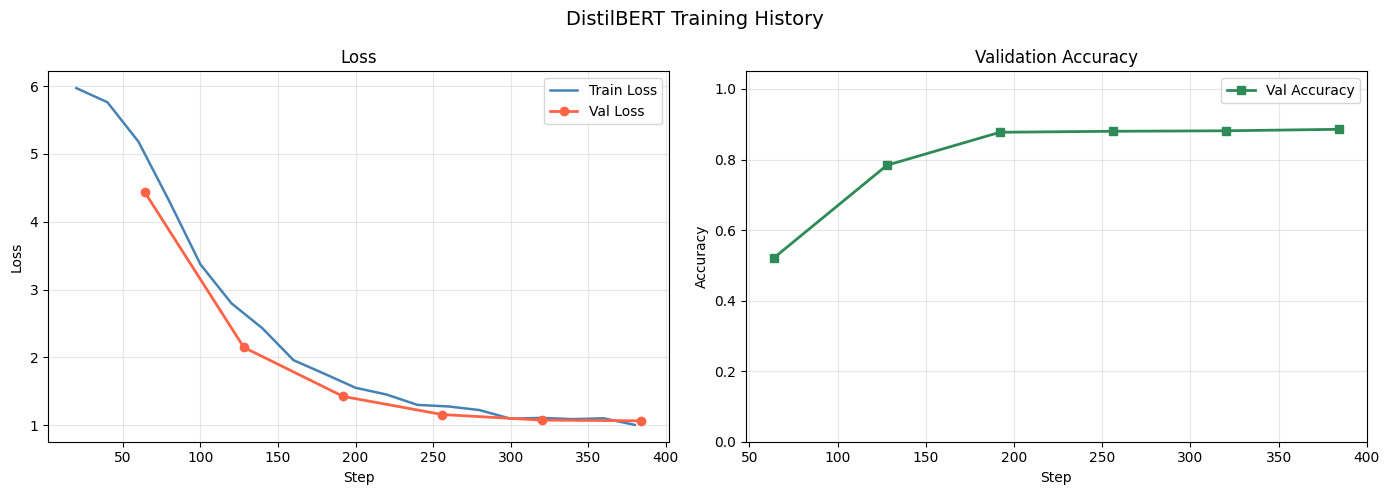

 Training curves & history saved.


In [12]:
try:
    cm          = confusion_matrix(y_true, y_pred)
    class_names_bert = list(le.classes_)

    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=class_names_bert, yticklabels=class_names_bert,
        linewidths=0.4, ax=ax,
    )
    ax.set_title("Confusion Matrix — DistilBERT Validation Set", fontsize=15, pad=12)
    ax.set_xlabel("Predicted Label", fontsize=12)
    ax.set_ylabel("True Label", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"{DISTILBERT_OUT}/confusion_matrix.png", dpi=150)
    plt.show()
    print(f"Confusion matrix saved.")
except Exception as e:
    print(f"Confusion matrix plot failed: {e}")

try:
    log_history = trainer.state.log_history
    train_logs  = [e for e in log_history if "loss"      in e and "eval_loss" not in e]
    eval_logs   = [e for e in log_history if "eval_loss" in e]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("DistilBERT Training History", fontsize=14)

    if train_logs:
        axes[0].plot([e["step"] for e in train_logs],
                     [e["loss"] for e in train_logs],
                     color="steelblue", linewidth=1.8, label="Train Loss")
    if eval_logs:
        axes[0].plot([e["step"]      for e in eval_logs],
                     [e["eval_loss"] for e in eval_logs],
                     color="tomato", linewidth=2, marker="o", label="Val Loss")
    axes[0].set_title("Loss"); axes[0].set_xlabel("Step"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(alpha=0.3)

    if eval_logs and "eval_accuracy" in eval_logs[0]:
        axes[1].plot([e["step"]          for e in eval_logs],
                     [e["eval_accuracy"] for e in eval_logs],
                     color="seagreen", linewidth=2, marker="s", label="Val Accuracy")
        axes[1].set_ylim(0, 1.05)
        axes[1].set_title("Validation Accuracy")
        axes[1].set_xlabel("Step"); axes[1].set_ylabel("Accuracy")
        axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{DISTILBERT_OUT}/training_curves.png", dpi=150)
    plt.show()

    with open(f"{DISTILBERT_OUT}/training_history.json", "w") as f:
        json.dump(log_history, f, indent=2)
    print(f" Training curves & history saved.")
except Exception as e:
    print(f"Training plot failed: {e}")


In [13]:

DISTILBERT_H5 = os.path.join(DISTILBERT_OUT, "distilbert_model.h5")

try:
    # Extract text embeddings from the full dataset and store in HDF5
    bert_clf.eval()
    bert_clf.to(DEVICE)

    all_texts = df_text["text"].tolist()
    all_vecs  = []
    EMBED_BATCH = 32

    print("Extracting DistilBERT ")
    base_bert = DistilBertModel.from_pretrained(DISTILBERT_OUT).to(DEVICE).eval()

    with torch.no_grad():
        for i in tqdm(range(0, len(all_texts), EMBED_BATCH)):
            enc = tokenizer(
                all_texts[i : i + EMBED_BATCH],
                padding=True, truncation=True,
                max_length=MAX_LENGTH, return_tensors="pt"
            ).to(DEVICE)
            out = base_bert(**enc)
            cls = out.last_hidden_state[:, 0, :].cpu().numpy()
            all_vecs.append(cls)

    text_features = np.concatenate(all_vecs, axis=0)

    with h5py.File(DISTILBERT_H5, "w") as hf:
        hf.create_dataset("text_features",  data=text_features)
        hf.create_dataset("labels_int",     data=df_text["label"].values)
        hf.create_dataset("labels_str",     data=np.array(df_text["label_str"].tolist(), dtype="S"))
        hf.create_dataset("class_names",    data=np.array(le.classes_.tolist(), dtype="S"))
        cfg = hf.create_group("config")
        cfg.attrs["model_name"]   = MODEL_NAME
        cfg.attrs["max_length"]   = MAX_LENGTH
        cfg.attrs["feature_dim"]  = text_features.shape[1]
        cfg.attrs["n_samples"]    = text_features.shape[0]
        cfg.attrs["n_classes"]    = len(le.classes_)

    size_mb = os.path.getsize(DISTILBERT_H5) / 1e6
    print(f"\ndistilbert_model.h5 saved!")
    print(f"   Path        : {DISTILBERT_H5}")
    print(f"   Size        : {size_mb:.2f} MB")
    print(f"   Embeddings  : {text_features.shape}  (samples × 768 dims)")

    np.save(f"{DISTILBERT_OUT}/text_features.npy", text_features)
    print(f"   NPY backup  : {DISTILBERT_OUT}/text_features.npy")

except Exception as e:
    print(f" DistilBERT .h5 export failed: {e}")


Extracting DistilBERT 


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: /kaggle/working/distilbert_output
Key                   | Status     |  | 
----------------------+------------+--+-
classifier.weight     | UNEXPECTED |  | 
pre_classifier.weight | UNEXPECTED |  | 
pre_classifier.bias   | UNEXPECTED |  | 
classifier.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 150/150 [00:05<00:00, 27.11it/s]



distilbert_model.h5 saved!
   Path        : /kaggle/working/distilbert_output/distilbert_model.h5
   Size        : 14.76 MB
   Embeddings  : (4775, 768)  (samples × 768 dims)
   NPY backup  : /kaggle/working/distilbert_output/text_features.npy


In [14]:

def recommend_category(user_query, top_k=3):
    try:
        inputs = tokenizer(
            user_query, return_tensors="pt",
            padding="max_length", truncation=True, max_length=MAX_LENGTH,
        ).to(DEVICE)

        bert_clf.eval()
        bert_clf.to(DEVICE)

        with torch.no_grad():
            logits = bert_clf(**inputs).logits

        probs       = torch.softmax(logits, dim=-1).squeeze().cpu().numpy()
        top_indices = np.argsort(probs)[::-1][:top_k]

        return {
            "query"        : user_query,
            "top_category" : le.classes_[top_indices[0]],
            "confidence"   : float(probs[top_indices[0]]),
            "top_k_results": [
                {"category": le.classes_[i], "confidence": round(float(probs[i]), 4)}
                for i in top_indices
            ],
        }
    except Exception as e:
        return {"error": str(e), "query": user_query}


demo_queries = [
    "I need a vegan soy milk substitute",
    "looking for dark chocolate with nuts",
    "best olive oil for cooking",
    "low sugar strawberry jam",
    "protein-rich Greek yogurt",
    "gluten-free pasta for a diet meal",
    "spicy tomato sauce for pizza",
    "organic honey for tea",
]

print("=" * 70)
print("CHATBOT RECOMMENDATION DEMO")
for q in demo_queries:
    res = recommend_category(q, top_k=3)
    if "error" in res:
        print(f"\nError for '{q}': {res['error']}")
        continue
    top3 = " | ".join(
        f"{r['category']} ({r['confidence']*100:.1f}%)"
        for r in res["top_k_results"]
    )
    print(f"\nQuery  : {res['query']}")
    print(f"  → {res['top_category'].upper()}  ({res['confidence']*100:.1f}%)")
    print(f"  Top-3  : {top3}")


CHATBOT RECOMMENDATION DEMO

Query  : I need a vegan soy milk substitute
  → MILK  (38.1%)
  Top-3  : milk (38.1%) | pasta (8.9%) | sugar (7.7%)

Query  : looking for dark chocolate with nuts
  → CHOCOLATE  (52.0%)
  Top-3  : chocolate (52.0%) | nuts (7.7%) | biscuits (5.7%)

Query  : best olive oil for cooking
  → OIL  (37.1%)
  Top-3  : oil (37.1%) | soap (12.8%) | sugar (7.2%)

Query  : low sugar strawberry jam
  → JAM  (64.4%)
  Top-3  : jam (64.4%) | sauce (4.3%) | yogurt (3.7%)

Query  : protein-rich Greek yogurt
  → YOGURT  (55.3%)
  Top-3  : yogurt (55.3%) | chips (5.5%) | rice (3.5%)

Query  : gluten-free pasta for a diet meal
  → PASTA  (71.2%)
  Top-3  : pasta (71.2%) | sauce (4.7%) | rice (3.9%)

Query  : spicy tomato sauce for pizza
  → SAUCE  (88.9%)
  Top-3  : sauce (88.9%) | pasta (2.1%) | rice (1.3%)

Query  : organic honey for tea
  → HONEY  (93.1%)
  Top-3  : honey (93.1%) | sauce (0.7%) | nuts (0.6%)


##  Section 3 — ResNet50 Image Feature Extractor

In [15]:

def scan_dataset(dataset_dir, valid_exts):
  
    image_paths, labels = [], []
    dataset_dir = Path(dataset_dir)

    if not dataset_dir.exists():
        raise FileNotFoundError(
            f"Dataset not found: {dataset_dir}\n"
        )

    for class_dir in sorted(dataset_dir.iterdir()):
        if not class_dir.is_dir():
            continue
        for img_file in sorted(class_dir.iterdir()):
            if img_file.suffix.lower() in valid_exts:
                image_paths.append(str(img_file))
                labels.append(class_dir.name)

    if not image_paths:
        raise ValueError(
            f"No images found in {dataset_dir}\n"
        )

    return image_paths, labels


try:
    image_paths, labels = scan_dataset(DATASET_DIR, VALID_EXTS)

    le_img       = LabelEncoder()
    labels_int   = le_img.fit_transform(labels)
    class_names  = le_img.classes_
    n_classes    = len(class_names)

    print(f" Dataset scanned")
    print(f"   Total images  : {len(image_paths):,}")
    print(f"   Total classes : {n_classes}")
    print()
    print(f"{'Class':<25} {'Count':>6}")
    print("-" * 33)
    for cls in class_names:
        cnt = labels.count(cls)
        print(f"{cls:<25} {cnt:>6}")

except FileNotFoundError as e:
    print(f" Dataset not found: {e}")
    image_paths, labels, labels_int, class_names, n_classes = [], [], [], [], 0
except Exception as e:
    print(f"Scan failed: {e}")
    raise


 Dataset scanned
   Total images  : 3,693
   Total classes : 20

Class                      Count
---------------------------------
biscuits                      53
bread                         78
butter                        93
cheese                       138
chips                        242
chocolate                    317
flour                        162
honey                        230
jam                          293
juice                        305
milk                         207
nuts                         203
oil                          150
pasta                        218
rice                         215
sauce                        227
soap                          59
spices                       247
sugar                        174
yogurt                        82


In [16]:
def compute_blur_score(path):
    try:
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return 0.0
        return float(cv2.Laplacian(img, cv2.CV_64F).var())
    except Exception:
        return 0.0


def check_image_quality(image_paths, expected_size=None):
    records = []
    bad_idx = []
    widths, heights = [], []

    for i, path in enumerate(tqdm(image_paths, desc="Quality check")):
        try:
            img = cv2.imread(path)
            if img is None:
                records.append({"path": path, "status": "unreadable",
                                "width": 0, "height": 0, "channels": 0})
                bad_idx.append(i)
                continue

            h, w = img.shape[:2]
            ch   = img.shape[2] if img.ndim == 3 else 1
            widths.append(w)
            heights.append(h)

            ok     = True
            status = "ok"
            if expected_size and (w != expected_size or h != expected_size):
                ok     = False
                status = "wrong_size"
            if ch != 3:
                ok     = False
                status = "wrong_channels"

            records.append({"path": path, "status": status,
                            "width": w, "height": h, "channels": ch})
            if not ok:
                bad_idx.append(i)

        except Exception as e:
            records.append({"path": path, "status": f"error:{e}",
                            "width": 0, "height": 0, "channels": 0})
            bad_idx.append(i)

    return pd.DataFrame(records), bad_idx, widths, heights


try:
    BLUR_THRESHOLD = 50.0
    quality_df, bad_idx, widths, heights = check_image_quality(image_paths)

    bad_set      = set(bad_idx)
    clean_idx    = [i for i in range(len(image_paths)) if i not in bad_set]
    clean_paths  = [image_paths[i] for i in clean_idx]
    clean_labels = [labels[i] for i in clean_idx]
    clean_lint   = labels_int[clean_idx]

    print(f" Quality check done")
    print(f"   Total  : {len(image_paths):,}")
    print(f"   Bad    : {len(bad_idx)}")
    print(f"   Clean  : {len(clean_paths):,}")

    blur_scores = [compute_blur_score(p) for p in tqdm(clean_paths, desc="Blur check")]
    n_blurry    = sum(1 for s in blur_scores if s < BLUR_THRESHOLD)
    print(f"   Blurry : {n_blurry} ({100 * n_blurry / max(len(clean_paths), 1):.1f}%)")

except Exception as e:
    print(f" Quality check failed: {e}")
    clean_paths  = image_paths
    clean_labels = labels
    clean_lint   = labels_int


Quality check: 100%|██████████| 3693/3693 [00:38<00:00, 95.93it/s] 


 Quality check done
   Total  : 3,693
   Bad    : 0
   Clean  : 3,693


Blur check: 100%|██████████| 3693/3693 [00:15<00:00, 244.02it/s]

   Blurry : 0 (0.0%)


In [17]:

def build_feature_extractor(image_size=224, freeze_all=True):
   
    try:
        base = ResNet50(
            weights="imagenet",
            include_top=False,
            input_shape=(image_size, image_size, 3),
        )

        if freeze_all:
            base.trainable = False
            print(f"  All {len(base.layers)} ResNet50 layers frozen.")
        else:
            base.trainable = True
            for layer in base.layers:
                if "conv5_block" not in layer.name:
                    layer.trainable = False
            n_trainable = sum(1 for l in base.layers if l.trainable)
            print(f"  Unfrozen: {n_trainable} layers (conv5_block only).")

        x     = GlobalAveragePooling2D(name="feature_vector")(base.output)
        model = Model(inputs=base.input, outputs=x, name="ResNet50_FeatureExtractor")
        return model

    except Exception as e:
        print(f" Failed to build ResNet50: {e}")
        raise


try:
    feature_extractor = build_feature_extractor(IMAGE_SIZE, FREEZE_ALL)

    total     = feature_extractor.count_params()
    trainable_p = sum(
        tf.keras.backend.count_params(w) for w in feature_extractor.trainable_weights
    )
    print(f"\n Feature extractor ready")
    print(f"   Output shape     : {feature_extractor.output_shape}")
    print(f"   Total params     : {total:,}")
    print(f"   Trainable params : {trainable_p:,}")
    print(f"   Frozen params    : {total - trainable_p:,}")

except Exception as e:
    print(f" Feature extractor failed: {e}")
    raise


I0000 00:00:1777679201.891550      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 11953 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777679201.896829      22 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 12645 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
  All 175 ResNet50 layers frozen.

 Feature extractor ready
   Output shape     : (None, 2048)
   Total params     : 23,587,712
   Trainable params : 0
   Frozen params    : 23,587,712


In [18]:
def load_and_preprocess_image(path, image_size):
    try:
        img = load_img(path, target_size=(image_size, image_size))
        arr = img_to_array(img)
        return preprocess_input(arr)
    except Exception as e:
        print(f"Could not load image: {path}  ({e})")
        return np.zeros((image_size, image_size, 3), dtype=np.float32)


def extract_features_batched(model, paths, image_size, batch_size):
    all_feats = []  # ← was missing, caused NameError
    n_batches = int(np.ceil(len(paths) / batch_size))

    for i in tqdm(range(n_batches), desc="Extracting features"):
        batch_paths = paths[i * batch_size : (i + 1) * batch_size]
        try:
            batch_arr = np.stack(
                [load_and_preprocess_image(p, image_size) for p in batch_paths]
            )
            feats = model.predict(batch_arr, verbose=0)
            all_feats.append(feats)
        except Exception as e:
            print(f"  Batch {i} failed: {e} — skipping batch")

    return np.vstack(all_feats) if all_feats else np.empty((0, 2048))


try:
    print(f"Extracting features from {len(clean_paths):,} images...")
    print(f"Image size: {IMAGE_SIZE}×{IMAGE_SIZE} | Batch size: {BATCH_SIZE}\n")

    image_features = extract_features_batched(
        feature_extractor, clean_paths, IMAGE_SIZE, BATCH_SIZE
    )

    print(f"   Feature matrix  : {image_features.shape}")
    print(f"   Dtype           : {image_features.dtype}")
    print(f"   Value range     : [{image_features.min():.4f}, {image_features.max():.4f}]")
    print(f"   Memory usage    : {image_features.nbytes / 1e6:.1f} MB")

except Exception as e:
    print(f" Feature extraction failed: {e}")
    raise

Extracting features from 3,693 images...
Image size: 224×224 | Batch size: 32



Extracting features:   0%|          | 0/116 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1777679208.222565    1498 service.cc:152] XLA service 0x79e98c019750 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777679208.222623    1498 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777679208.222630    1498 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777679209.148239    1498 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777679214.201871    1498 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
Extracting features: 100%|██████████| 116/116 [00:48<00:00,  2.38it/s]

   Feature matrix  : (3693, 2048)
   Dtype           : float32
   Value range     : [0.0000, 27.6196]
   Memory usage    : 30.3 MB


In [19]:

tag = f"img{IMAGE_SIZE}_bs{BATCH_SIZE}_{'frozen' if FREEZE_ALL else 'finetune'}"

try:
    np.save(f"{RESNET_OUT}/features_resnet50_{tag}.npy", image_features)
    np.save(f"{RESNET_OUT}/labels_int.npy",  clean_lint)
    np.save(f"{RESNET_OUT}/labels_str.npy",  np.array(clean_labels))
    np.save(f"{RESNET_OUT}/class_names.npy", class_names)
    np.save(f"{RESNET_OUT}/image_paths.npy", np.array(clean_paths))
except Exception as e:
    print(f"NPY save failed: {e}")

RESNET_H5 = os.path.join(RESNET_OUT, "resnet_model.h5")
try:
    with h5py.File(RESNET_H5, "w") as hf:
        hf.create_dataset("image_features", data=image_features)
        hf.create_dataset("labels_int",     data=clean_lint)
        hf.create_dataset("labels_str",     data=np.array(clean_labels, dtype="S"))
        hf.create_dataset("class_names",    data=np.array(class_names.tolist(), dtype="S"))
        hf.create_dataset("image_paths",    data=np.array(clean_paths, dtype="S"))
        cfg = hf.create_group("config")
        cfg.attrs["image_size"]   = IMAGE_SIZE
        cfg.attrs["batch_size"]   = BATCH_SIZE
        cfg.attrs["freeze_all"]   = int(FREEZE_ALL)
        cfg.attrs["feature_dim"]  = image_features.shape[1]
        cfg.attrs["n_samples"]    = image_features.shape[0]
        cfg.attrs["n_classes"]    = len(class_names)
        cfg.attrs["tag"]          = tag

    size_mb = os.path.getsize(RESNET_H5) / 1e6
    print(f"\nresnet_model.h5 saved!")
    print(f"   Path        : {RESNET_H5}")
    print(f"   Size        : {size_mb:.2f} MB")
    print(f"   Features    : {image_features.shape}")

except Exception as e:
    print(f" ResNet .h5 save failed: {e}")


 ResNet .h5 save failed: 'ascii' codec can't encode character '\xe8' in position 112: ordinal not in range(128)


## Section 4 — Fusion Model (Text + Image Combined)

In [20]:

try:
    feat_file = f"{RESNET_OUT}/features_resnet50_{tag}.npy"
    if os.path.exists(feat_file):
        img_feats_fusion = np.load(feat_file)
    else:
        img_feats_fusion = image_features

    lbl_int_fusion  = np.load(f"{RESNET_OUT}/labels_int.npy")
    lbl_str_fusion  = np.load(f"{RESNET_OUT}/labels_str.npy",  allow_pickle=True)
    cls_fusion      = np.load(f"{RESNET_OUT}/class_names.npy", allow_pickle=True)
    print(f"Image features loaded  : {img_feats_fusion.shape}")

except Exception as e:
    print(f" Image features load failed: {e}")
    img_feats_fusion = image_features
    lbl_int_fusion   = clean_lint
    lbl_str_fusion   = np.array(clean_labels)
    cls_fusion       = class_names

try:
    txt_feat_file = f"{DISTILBERT_OUT}/text_features.npy"
    if os.path.exists(txt_feat_file):
        txt_feats_fusion = np.load(txt_feat_file)
        print(f"Text features loaded   : {txt_feats_fusion.shape}")
    else:
        raise FileNotFoundError(" not found.")

except Exception as e:
    print(f" Text features not found: {e}")

    try:
        df_hdf = pd.read_hdf(f"{DISTILBERT_OUT}/Data20categories.h5", key="df")
        texts_fuse = df_hdf["keyword"].astype(str).tolist()

        tok_fuse  = DistilBertTokenizer.from_pretrained(DISTILBERT_OUT)
        bert_fuse = DistilBertModel.from_pretrained(DISTILBERT_OUT).to(DEVICE).eval()

        vecs = []
        with torch.no_grad():
            for i in tqdm(range(0, len(texts_fuse), 32), desc="Embedding text"):
                enc = tok_fuse(
                    texts_fuse[i:i+32], padding=True, truncation=True,
                    max_length=MAX_LENGTH, return_tensors="pt"
                ).to(DEVICE)
                out = bert_fuse(**enc)
                vecs.append(out.last_hidden_state[:, 0, :].cpu().numpy())

        txt_feats_fusion = np.concatenate(vecs, axis=0)
        np.save(f"{DISTILBERT_OUT}/text_features.npy", txt_feats_fusion)
        print(f"Text features generated : {txt_feats_fusion.shape}")

    except Exception as e2:
        print(f"Text feature generation failed: {e2}")
        N = img_feats_fusion.shape[0]
        txt_feats_fusion = np.random.rand(N, 768).astype("float32")
        print(f"  Using mock text features: {txt_feats_fusion.shape}")


Image features loaded  : (3693, 2048)
Text features loaded   : (4775, 768)


In [21]:
try:
    N_img = img_feats_fusion.shape[0]
    N_txt = txt_feats_fusion.shape[0]

    print(f"Image features : {img_feats_fusion.shape}")
    print(f"Text features  : {txt_feats_fusion.shape}")

    # Align if sizes differ (truncate to the smaller)
    if N_img != N_txt:
        N_min = min(N_img, N_txt)
        print(f"\n  Sample count mismatch ({N_img} vs {N_txt}) — truncating to {N_min}.")
        img_feats_fusion = img_feats_fusion[:N_min]
        txt_feats_fusion = txt_feats_fusion[:N_min]
        lbl_int_fusion   = lbl_int_fusion[:N_min]
        lbl_str_fusion   = lbl_str_fusion[:N_min]

    # Concatenate text (768) + image (2048) → fused (2816)
    fused_features = np.concatenate([txt_feats_fusion, img_feats_fusion], axis=1)

    print(f"   Text dim    : {txt_feats_fusion.shape[1]}")
    print(f"   Image dim   : {img_feats_fusion.shape[1]}")
    print(f"   Fused dim   : {fused_features.shape[1]}")
    print(f"   Samples     : {fused_features.shape[0]:,}")
    print(f"   Memory      : {fused_features.nbytes / 1e6:.1f} MB")

except Exception as e:
    print(f"Feature fusion failed: {e}")
    raise


Image features : (3693, 2048)
Text features  : (4775, 768)

  Sample count mismatch (3693 vs 4775) — truncating to 3693.
   Text dim    : 768
   Image dim   : 2048
   Fused dim   : 2816
   Samples     : 3,693
   Memory      : 41.6 MB


In [22]:
COMBINED_H5 = os.path.join(FUSION_OUT, "combined_model.h5")

try:
    with h5py.File(COMBINED_H5, "w") as hf:
        hf.create_dataset("fused_features",   data=fused_features)
        hf.create_dataset("text_features",    data=txt_feats_fusion)
        hf.create_dataset("image_features",   data=img_feats_fusion)
        hf.create_dataset("labels_int",       data=lbl_int_fusion)
        hf.create_dataset("labels_str",       data=np.array(lbl_str_fusion.tolist(), dtype="S"))
        hf.create_dataset("class_names",      data=np.array(cls_fusion.tolist(), dtype="S"))

        cfg = hf.create_group("config")
        cfg.attrs["text_dim"]    = txt_feats_fusion.shape[1]
        cfg.attrs["image_dim"]   = img_feats_fusion.shape[1]
        cfg.attrs["fused_dim"]   = fused_features.shape[1]
        cfg.attrs["n_samples"]   = fused_features.shape[0]
        cfg.attrs["n_classes"]   = len(cls_fusion)

    size_mb = os.path.getsize(COMBINED_H5) / 1e6
    print(f" combined_model.h5 saved!")
    print(f"   Path        : {COMBINED_H5}")
    print(f"   Size        : {size_mb:.2f} MB")
    print(f"   text({txt_feats_fusion.shape[1]}) + image({img_feats_fusion.shape[1]}) = fused({fused_features.shape[1]})")

except Exception as e:
    print(f" combined_model.h5 save failed: {e}")


 combined_model.h5 saved!
   Path        : /kaggle/working/fusion_output/combined_model.h5
   Size        : 83.26 MB
   text(768) + image(2048) = fused(2816)
